# Curve Fitting and Least Squares Regression

The term least squares describes a frequently used approach to solving overdetermined or inexactly specified systems of equations in an approximate sense. Instead of solving the equations exactly, we seek only to minimize the sum of the squares of the residuals. The least squares criterion has important statistical interpretations. If appropriate probabilistic assumptions about underlying error distributions are made, least squares produces what is known as the maximum-likelihood estimate of the parameters. Even if the probabilistic assumptions are not satisfied, years of experience have shown that least squares produces useful results.

Traditional methods use a **line of best fit** to fit through a set of data. In most situations, however, a line is not the best fit for data. Usually we will try to fit some kind of curve to the data. This can be done to estimate some trend, or uncover some law underlying the observations. For example, one might try to fit population data with an exponential function to try to predict the future population. The method of least-squares can be used in these cases as well.

Let's begin with implementing a basic **linear regression** model.

---

Slope (Coefficient): 870.00
Intercept: 710.00
Prediction for 6: 5930.00


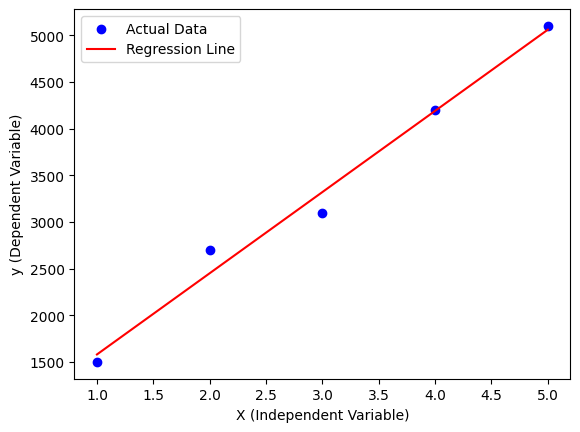

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Prepare sample data (X must be 2D for scikit-learn)
X = np.array([[1], [2], [3], [4], [5]])  # Feature: e.g., Years of Experience
y = np.array([1500, 2700, 3100, 4200, 5100])  # Target: e.g., Salary

# 2. Initialize and fit the model
model = LinearRegression()
model.fit(X, y)

# 3. Extract model parameters
print(f"Slope (Coefficient): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

# 4. Make a prediction for a new value (e.g., 6 years of experience)
new_input = np.array([[6]])
prediction = model.predict(new_input)
print(f"Prediction for 6: {prediction[0]:.2f}")

# 5. Visualize the best-fit line
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X, model.predict(X), color="red", label="Regression Line")
plt.xlabel("X (Independent Variable)")
plt.ylabel("y (Dependent Variable)")
plt.legend()
plt.show()


# Polynomial Regression 

As mentioned before, in most scientific fields a line of best fit is not always linear. Sometimes we may need to use a polynomial of a higher degree to fit through a nonlinear set of data. 

A classic example of curve fitting to discover a natural law was performed by the German astronomer
Johannes Kepler in the early 1600’s. Kepler tried to make sense of the incredibly accurate (naked
eye!) observations of the Danish astronomer Tycho Brahe on the motion of the planets. Kepler found
that the data did not fit the prevailing geocentric models nor the heliocentric model of Copernicus.
These models were based on a 2000+ year old tradition that the motions of the planets were made
up of circles. Kepler proposed the revolutionary idea that the planets not only orbited the sun,
instead of the other way around, but that they did so in ellipses! This model fit the data better,
although not by that much! Kepler formulated three laws of planetary motion based on this model.
His third law states that the square of the orbital period of a planet is proportional to the cube of
the semi-major axis of its orbit. In other words,

$$T^2 \propto a^3 \quad \text{or} \quad T^2 = k \cdot a^3$$

*   **$T$** is the orbital period.
*   **$a$** is the semi-major axis.
*   **$k$** is the constant of proportionality.

Because this relationship is non-linear ($T = \sqrt{k} \cdot a^{1.5}$), standard linear regression is insufficient, requiring polynomial regression or transformations to model the data.


Log-Log Slope (Expected ~1.5): 1.500
Log-Log Intercept: -0.000


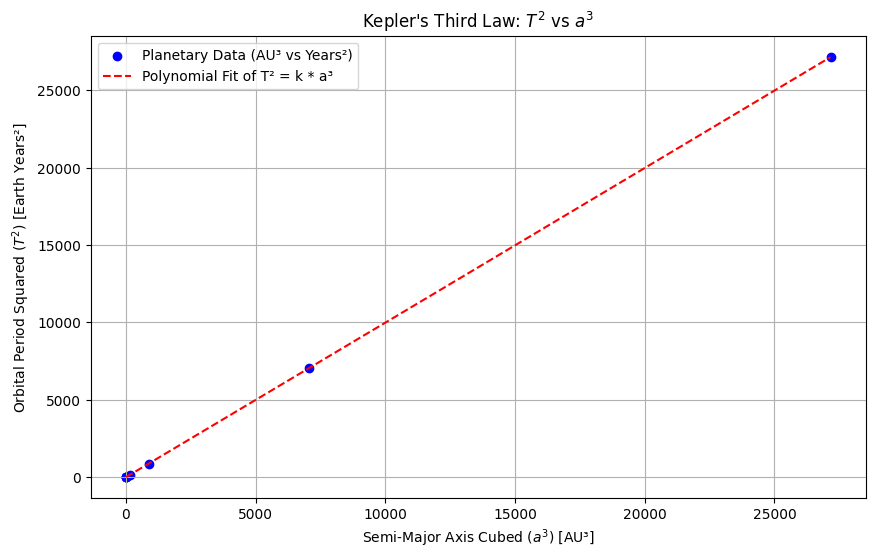

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# 1. Planetary data (Semi-major axis 'a' in AU, Period 'T' in Earth years)
# Data source: NASA / JPL
planets = ['Mercury', 'Venus', 'Earth', 'Mars', 'Jupiter', 'Saturn', 'Uranus', 'Neptune']
a = np.array([0.39, 0.72, 1.00, 1.52, 5.20, 9.54, 19.19, 30.06])
T = np.array([0.24, 0.62, 1.00, 1.88, 11.86, 29.46, 84.01, 164.79])

# 2. Transform the data according to Kepler's Law (T^2 vs a^3)
# To find the line, we can take the log of both sides: log(T) = 1.5 * log(a) + log(K)
log_a = np.log(a).reshape(-1, 1)
log_T = np.log(T)

# 3. Fit a linear regression to the log-log data
model = LinearRegression()
model.fit(log_a, log_T)

# Extract slope (should be exactly 1.5 according to Kepler's 3rd Law)
slope = model.coef_[0]
intercept = model.intercept_
print(f"Log-Log Slope (Expected ~1.5): {slope:.3f}")
print(f"Log-Log Intercept: {intercept:.3f}")

# 4. Predict and plot the original T^2 vs a^3 relationship
# We fit a 2nd degree polynomial to T^2 and a^3
X = a**3
y = T**2

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X.reshape(-1, 1))

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

# Generate values for plotting the curve
X_range = np.linspace(0, np.max(X), 100)
X_range_poly = poly.transform(X_range.reshape(-1, 1))
y_pred = poly_model.predict(X_range_poly)

# 5. Visualization
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Planetary Data (AU³ vs Years²)')
plt.plot(X_range, y_pred, color='red', linestyle='--', label=f'Polynomial Fit of T² = k * a³')
plt.title("Kepler's Third Law: $T^2$ vs $a^3$")
plt.xlabel("Semi-Major Axis Cubed ($a^3$) [AU³]")
plt.ylabel("Orbital Period Squared ($T^2$) [Earth Years²]")
plt.legend()
plt.grid(True)
plt.show()


Fitted constant k = 0.9994 ± 0.0005


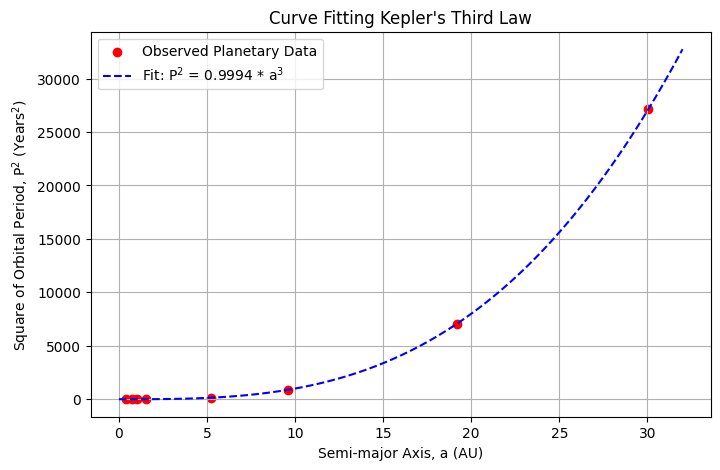

In [5]:
# YOUR TURN! Implement a polynomial regression model that fits through the same points without linear regression. 
# What kind of curve do you see?

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Define Kepler's Third Law function: P^2 = k * a^3
def kepler_law(a, k):
    return k * (a ** 3)

# 2. Example Data (Orbital distance 'a' in AU, Period 'P' in Earth years)
# For our solar system, k is approximately 1
a_data = np.array([0.39, 0.72, 1.00, 1.52, 5.20, 9.58, 19.22, 30.06])
P_data = np.array([0.24, 0.62, 1.00, 1.88, 11.86, 29.45, 84.02, 164.79])

# Square the periods to fit P^2
P_squared = P_data ** 2

# 3. Perform Curve Fitting
popt, pcov = curve_fit(kepler_law, a_data, P_squared)
k_fitted = popt[0]
k_error = np.sqrt(pcov[0, 0])

print(f"Fitted constant k = {k_fitted:.4f} ± {k_error:.4f}")

# 4. Visualization
a_range = np.linspace(0, 32, 100)
P_fit_squared = kepler_law(a_range, k_fitted)

plt.figure(figsize=(8, 5))
plt.scatter(a_data, P_squared, color='red', label='Observed Planetary Data')
plt.plot(a_range, P_fit_squared, color='blue', linestyle='--', label=f'Fit: P$^2$ = {k_fitted:.4f} * a$^3$')
plt.xlabel('Semi-major Axis, a (AU)')
plt.ylabel('Square of Orbital Period, P$^2$ (Years$^2$)')
plt.title("Curve Fitting Kepler's Third Law")
plt.legend()
plt.grid(True)
